# Heart Disease Prediction — Advanced Analysis, Statistical Validation & Feature Engineering
**AnalystLab Africa | Data Science Internship — Week 3**

Author: Junior Data Scientist, AnalystLab Africa Consulting

Week 2 left this dataset in two shapes: a clean, human-readable version
(`heart_cleaned.csv`) and a fully encoded/scaled version ready for a model
(`heart_ml_ready.csv`). This week I'm not touching that cleaning work again —
it's done, and the brief is explicit that I shouldn't repeat it unless this
week's analysis actually turns up a reason to. Instead I'm going a level
deeper: testing some of the patterns I only eyeballed in Week 2, engineering
a few new features that came out of that testing, and then deciding —
with evidence, not guesswork — which features (old and new) actually
earn a place in the dataset that Week 4's model will be trained on.

I'm working from `heart_cleaned.csv` rather than the ML-ready file, on
purpose. A lot of what's below (boxplots, chi-square tests, group medians)
needs the original readable categories and unscaled numbers to mean
anything — testing a chi-square on already-scaled, already-one-hot-encoded
columns would just be testing my own Week 2 preprocessing back at myself.
I rebuild the ML-ready encoding at the very end, once, after all of this
week's decisions are folded in.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


## 2. Project Continuity Recap

Quick recap before diving in — the full version of this is in the
**Project Continuity Summary** document, this is just the notebook-level
version so the analysis below makes sense standing on its own.

- **Business problem:** ABC Manufacturing Ltd is exploring an employee
  wellness/occupational health screening initiative. The question is
  whether clinical measurements can flag employees at meaningfully higher
  risk of heart disease early enough to act on it.
- **Target variable:** `HeartDisease` (1 = has heart disease, 0 = does not),
  reasonably balanced at 55.3% / 44.7%.
- **Week 1 (different dataset, same client):** looked at *employee
  attrition* using the IBM HR dataset. Not the thread this week continues
  — Week 2's brief allowed picking either the heart disease or the loan
  dataset, and I picked heart disease, which is what Week 3 builds on.
- **Week 2 key actions:** caught 172 rows (18.7%) where `Cholesterol` was
  disguised as 0 instead of genuinely missing, median-imputed it by chest
  pain type, capped a handful of high-end outliers in `RestingBP`,
  `Cholesterol` and `Oldpeak`, renamed a few cryptic columns
  (`FastingBS`→readable, `Oldpeak`→`ST_Depression`, `MaxHR`→`MaxHeartRate`
  in the ML-ready file), and engineered `AgeGroup` and `RiskFactorCount`.
- **Open questions carried into this week:** Week 2's correlation and
  Random Forest importance both pointed at `ST_Slope`, `ExerciseAngina`,
  `ST_Depression` (Oldpeak) and chest pain type as the strongest signals —
  but none of that was ever formally hypothesis-tested, and chest pain
  type was still sitting as an unordered one-hot category even though the
  four categories clearly don't carry equal risk. Both of those are what
  this notebook picks up.

## 3. Load Week 2's Cleaned Dataset

In [ ]:
df = pd.read_csv('heart_cleaned.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head(5)

Rows: 918, Columns: 12


In [ ]:
df.isnull().sum().sum(), df.duplicated().sum()

Zero missing values, zero duplicates — as expected, since this is already
the Week 2 output. `RestingBP` and `Cholesterol` are floats because of the
median imputation; everything else is unchanged from the raw file.

## 4. Advanced Exploratory Data Analysis

Week 1's EDA (on the HR dataset) and Week 2's exploration of this dataset
already covered the basics. The goal here is deeper: distribution shape,
skew, group comparisons and multivariate patterns that actually matter for
the statistical tests and features coming up in Parts 3 and 4.

### 4.1 Numerical Distributions, Skew & Variability

Age           -0.20
RestingBP      0.61
Cholesterol    1.42
MaxHR         -0.14
Oldpeak        1.02
dtype: float64


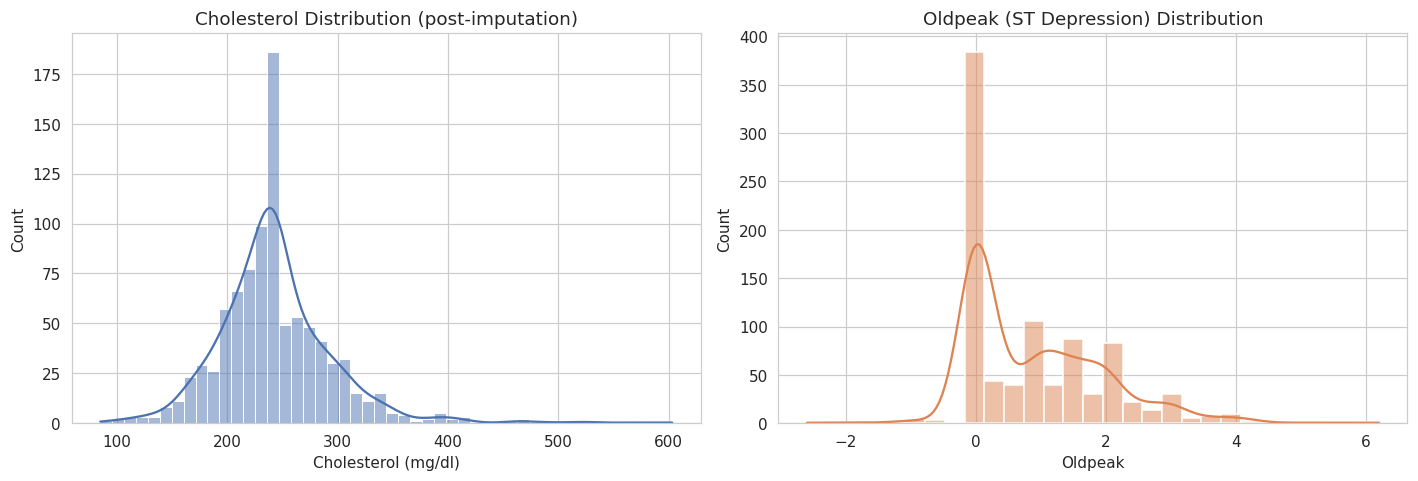

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['Cholesterol'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Cholesterol Distribution (post-imputation)')
axes[0].set_xlabel('Cholesterol (mg/dl)')
sns.histplot(df['Oldpeak'], kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Oldpeak (ST Depression) Distribution')
axes[1].set_xlabel('Oldpeak')
plt.tight_layout()
plt.show()

print(df[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']].skew().round(2))

Cholesterol still has a real right skew (skew ≈ 1.4) even after the
disguised-zero fix and outlier capping from Week 2 — makes sense, a
handful of patients genuinely run very high cholesterol and no amount of
correct cleaning should erase that, only the *fake* zeros needed fixing.
Oldpeak is skewed even harder (≈ 1.0) and has a floor at 0 for anyone who
showed no ST depression at all, which is most people. Age and MaxHR are
close to symmetric. This matters directly for Part 3 — skewed variables
are exactly why I lean on non-parametric tests below instead of assuming
a t-test is automatically fine.

### 4.2 Categorical Frequency Distributions

ChestPainType
ASY    54.0
NAP    22.1
ATA    18.8
TA      5.0
Name: proportion, dtype: float64


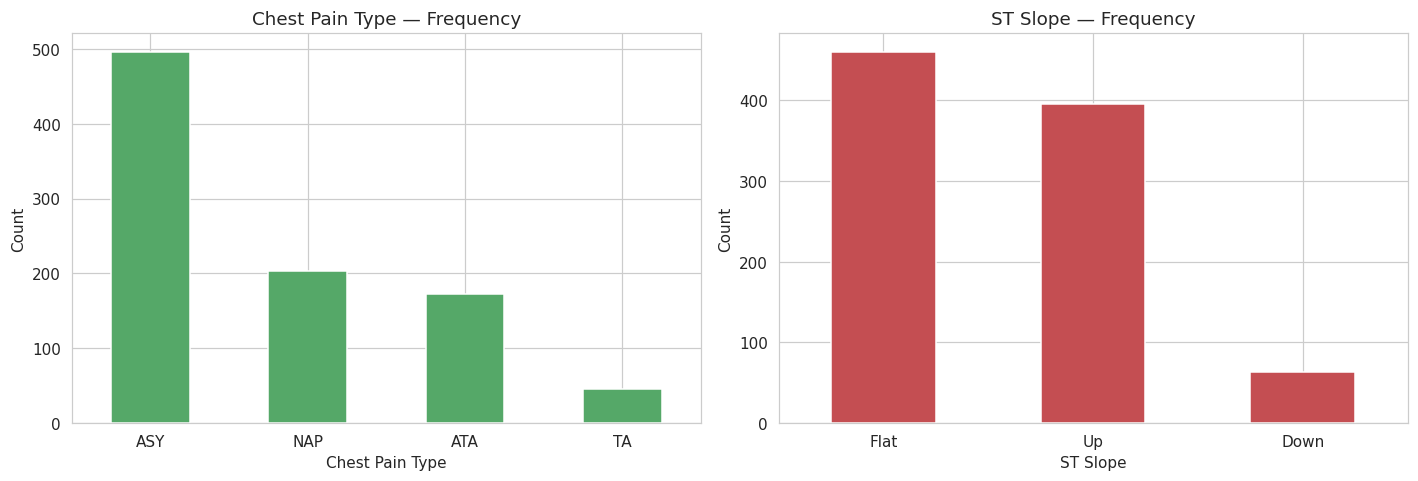

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df['ChestPainType'].value_counts().plot(kind='bar', ax=axes[0], color='#55A868')
axes[0].set_title('Chest Pain Type — Frequency')
axes[0].set_xlabel('Chest Pain Type'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['ST_Slope'].value_counts().plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('ST Slope — Frequency')
axes[1].set_xlabel('ST Slope'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print((df['ChestPainType'].value_counts(normalize=True) * 100).round(1))

ASY (asymptomatic — no textbook chest pain despite underlying disease) is
the single largest chest pain category at 54% of the dataset, which is a
little unsettling on its own: over half the patients here didn't present
with obvious chest pain symptoms. ST_Slope has a similar imbalance —
'Flat' and 'Up' dominate, 'Down' is rare (63 patients, 6.9%).

### 4.3 Bivariate Analysis — Numerical vs Target

              MaxHR  Oldpeak
HeartDisease                
0             150.0      0.0
1             126.0      1.2


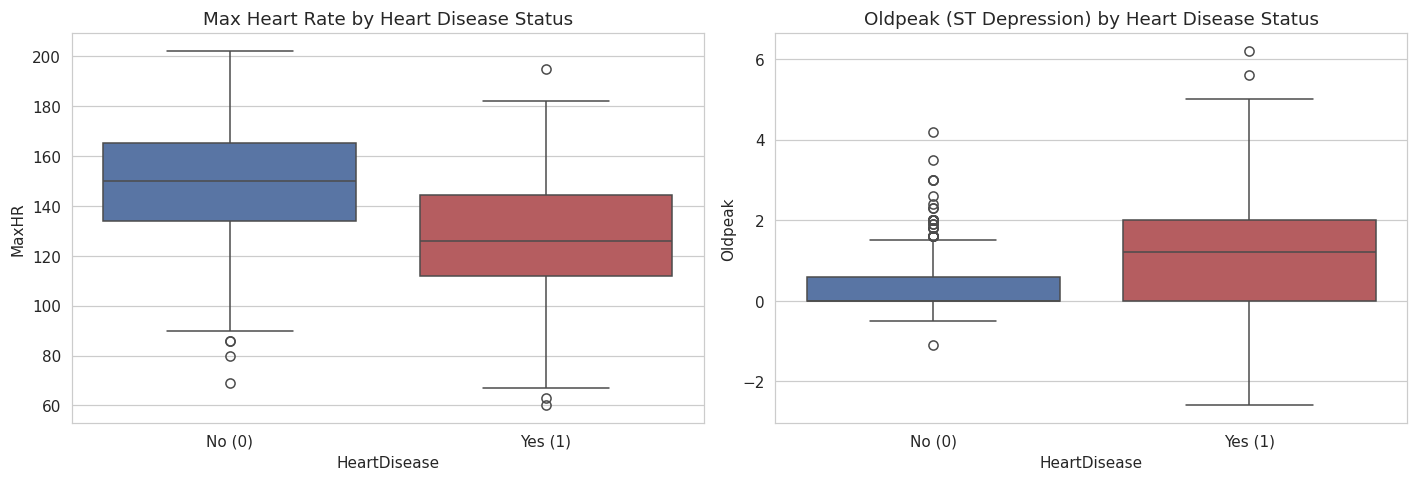

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x='HeartDisease', y='MaxHR', hue='HeartDisease', ax=axes[0], palette=['#4C72B0','#C44E52'], legend=False)
axes[0].set_title('Max Heart Rate by Heart Disease Status')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['No (0)', 'Yes (1)'])

sns.boxplot(data=df, x='HeartDisease', y='Oldpeak', hue='HeartDisease', ax=axes[1], palette=['#4C72B0','#C44E52'], legend=False)
axes[1].set_title('Oldpeak (ST Depression) by Heart Disease Status')
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

print(df.groupby('HeartDisease')[['MaxHR','Oldpeak']].median())

Both boxes shift a lot between groups. Patients with heart disease have a
visibly *lower* max heart rate under exercise (median 126 vs 150) and a
visibly *higher* Oldpeak (median 1.2 vs 0.0) — which lines up with how
these two variables are actually used clinically: a heart under strain
can't push its rate as high, and more of the ECG's ST segment depresses
under exertion. I'll test both of these formally in Part 3.

### 4.4 Bivariate Analysis — Categorical vs Target

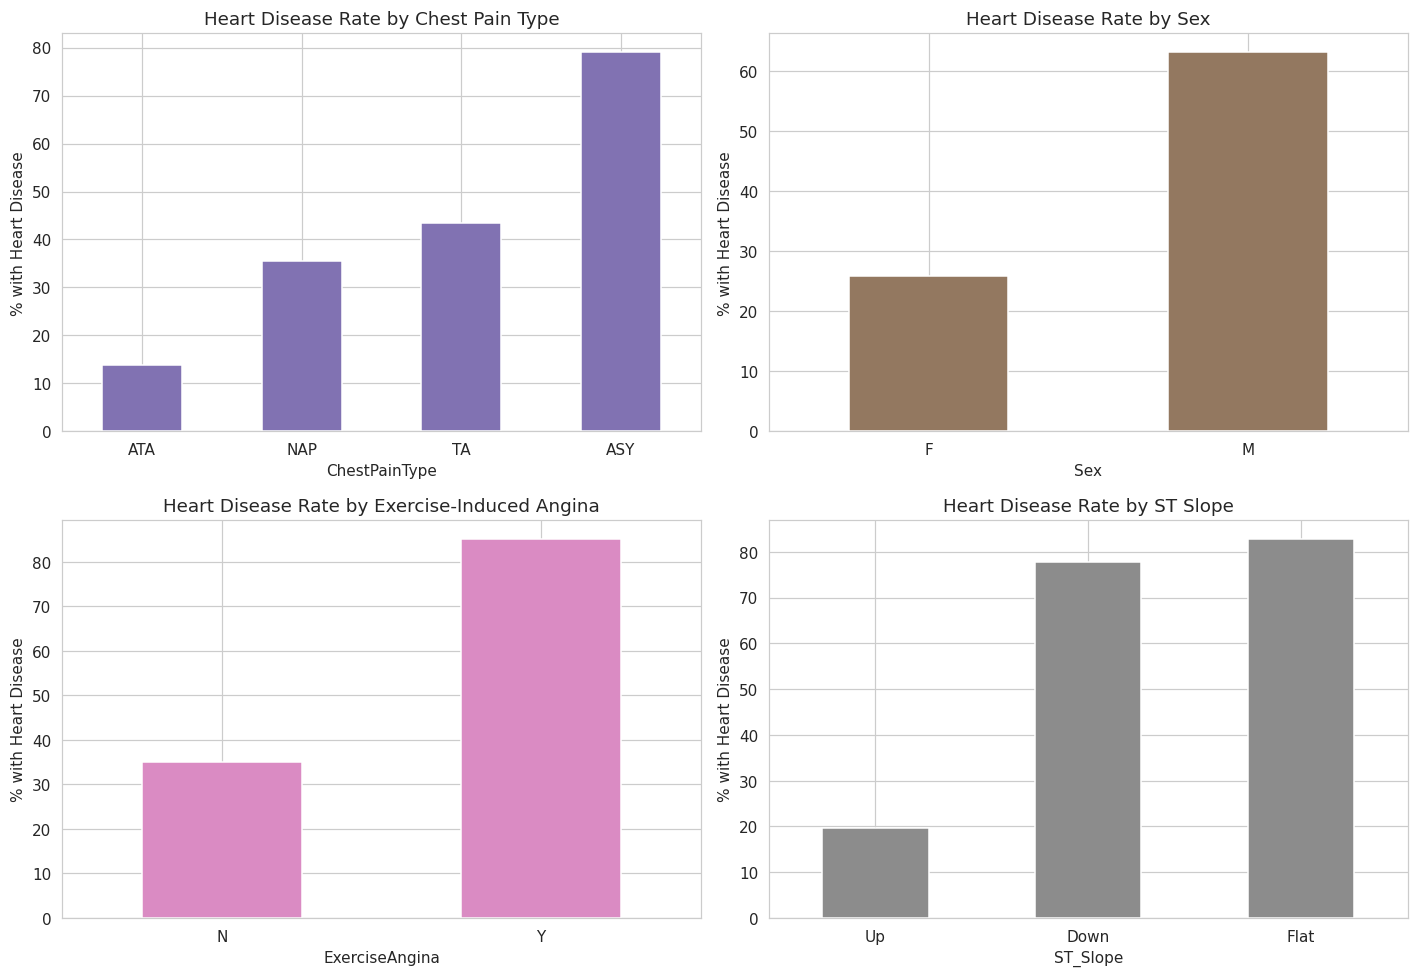

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

rate_cp = df.groupby('ChestPainType')['HeartDisease'].mean().sort_values() * 100
rate_cp.plot(kind='bar', ax=axes[0,0], color='#8172B2')
axes[0,0].set_title('Heart Disease Rate by Chest Pain Type')
axes[0,0].set_ylabel('% with Heart Disease'); axes[0,0].tick_params(axis='x', rotation=0)

rate_sex = df.groupby('Sex')['HeartDisease'].mean().sort_values() * 100
rate_sex.plot(kind='bar', ax=axes[0,1], color='#937860')
axes[0,1].set_title('Heart Disease Rate by Sex')
axes[0,1].set_ylabel('% with Heart Disease'); axes[0,1].tick_params(axis='x', rotation=0)

rate_ang = df.groupby('ExerciseAngina')['HeartDisease'].mean().sort_values() * 100
rate_ang.plot(kind='bar', ax=axes[1,0], color='#DA8BC3')
axes[1,0].set_title('Heart Disease Rate by Exercise-Induced Angina')
axes[1,0].set_ylabel('% with Heart Disease'); axes[1,0].tick_params(axis='x', rotation=0)

rate_slope = df.groupby('ST_Slope')['HeartDisease'].mean().sort_values() * 100
rate_slope.plot(kind='bar', ax=axes[1,1], color='#8C8C8C')
axes[1,1].set_title('Heart Disease Rate by ST Slope')
axes[1,1].set_ylabel('% with Heart Disease'); axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

This is where the deeper story starts to show up. Chest pain type isn't
just 'associated' with heart disease — it swings from a 13.9% rate (ATA)
to a 79.0% rate (ASY), a near six-fold difference across four categories,
and the categories fall into a clear order: ATA < NAP < TA < ASY. That
ordering is exactly what I turn into the `ChestPainRiskRank` feature in
Part 4. Sex shows a big gap too (63.2% of men vs 25.9% of women in this
sample), and both exercise angina and a flat/down ST slope are strongly
linked to higher rates. All four of these get formally tested in Part 3.

### 4.5 Multivariate Analysis

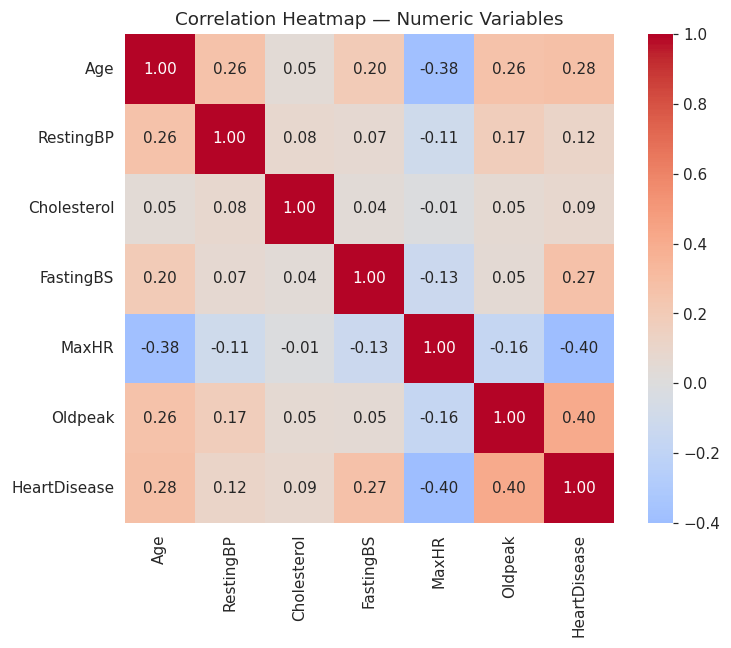

In [ ]:
plt.figure(figsize=(7.5, 6))
numeric_cols = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HeartDisease']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Numeric Variables')
plt.tight_layout()
plt.show()

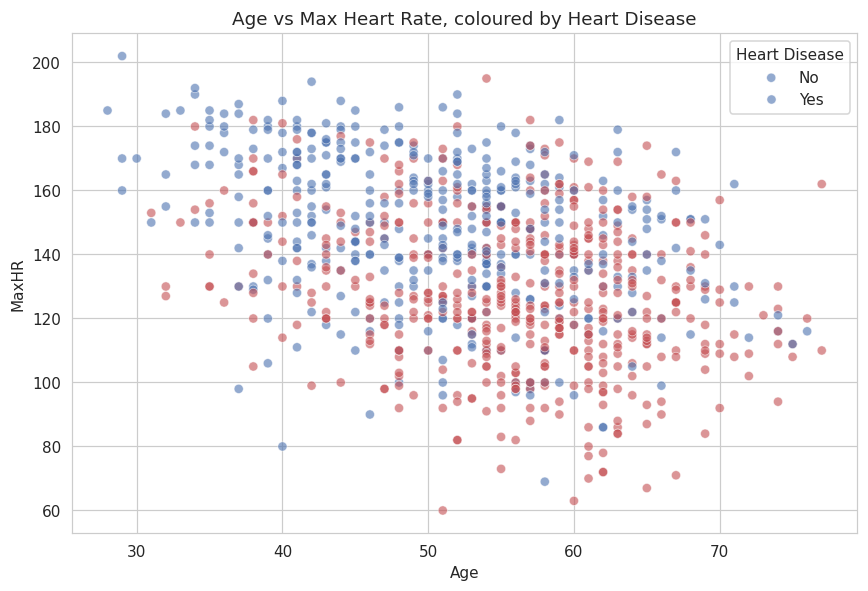

In [ ]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=df, x='Age', y='MaxHR', hue='HeartDisease',
                 palette=['#4C72B0','#C44E52'], alpha=0.6)
plt.title('Age vs Max Heart Rate, coloured by Heart Disease')
plt.legend(title='Heart Disease', labels=['No','Yes'])
plt.tight_layout()
plt.show()

No pair of the original numeric variables is anywhere near collinear
(everything under about ±0.4) — that's a genuinely useful multivariate
finding on its own, since it means Week 2's decision not to drop any
numeric column on redundancy grounds was the right call, and there's no
new reason to revisit it. The Age/MaxHR scatter shows both the expected
downward trend (max heart rate naturally drops with age) and the disease
split riding on top of it — the orange (disease) points sit systematically
below the blue (no disease) points at almost every age, which is a first
visual hint that MaxHR carries information about heart disease *beyond*
what age alone explains. I dig into that idea directly in Part 4.

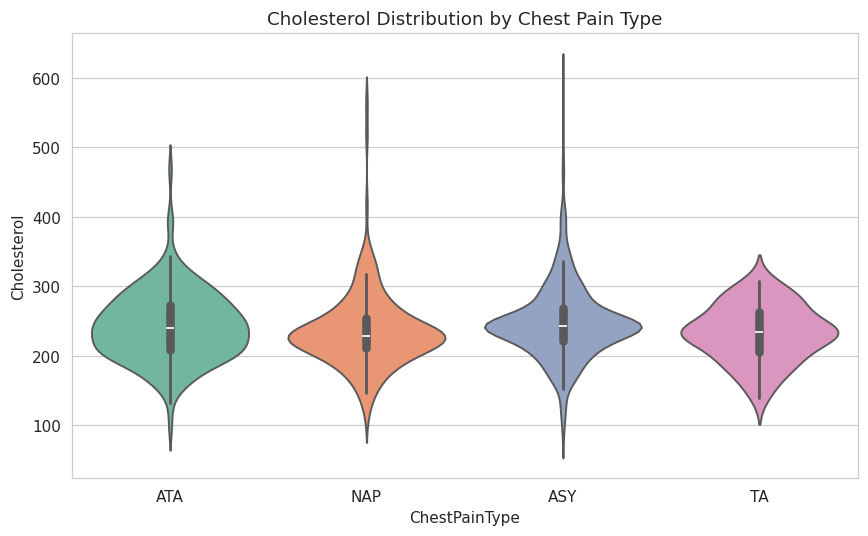

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='ChestPainType', y='Cholesterol', hue='ChestPainType', palette='Set2', legend=False)
plt.title('Cholesterol Distribution by Chest Pain Type')
plt.tight_layout()
plt.show()

The violin plot shows the ASY and ATA groups both carry a long high-end
tail — a handful of patients with genuinely very high cholesterol in each
group — but the medians across all four chest pain types sit close
together. Worth testing formally rather than eyeballing (Part 3, Test 5).

## 5. Statistical Hypothesis Testing & Validation

Six tests below, more than the minimum of four the brief asks for. Before
picking parametric vs non-parametric tests, I checked whether the
continuous variables involved are close enough to normal to justify a
t-test.

In [ ]:
for col in ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']:
    stat, p = stats.shapiro(df[col].sample(min(500, len(df)), random_state=RANDOM_STATE))
    verdict = 'roughly normal' if p > 0.05 else 'NOT normal'
    print(f"{col:12s} Shapiro-Wilk W={stat:.3f}  p={p:.4f}  -> {verdict}  (skew={df[col].skew():.2f})")

Age          Shapiro-Wilk W=0.991  p=0.0036  -> NOT normal  (skew=-0.20)
RestingBP    Shapiro-Wilk W=0.973  p=0.0000  -> NOT normal  (skew=0.61)
Cholesterol  Shapiro-Wilk W=0.914  p=0.0000  -> NOT normal  (skew=1.42)
MaxHR        Shapiro-Wilk W=0.991  p=0.0029  -> NOT normal  (skew=-0.14)
Oldpeak      Shapiro-Wilk W=0.865  p=0.0000  -> NOT normal  (skew=1.02)


Every single one fails the Shapiro-Wilk test at p < 0.05 — though with
918 rows, Shapiro is notoriously quick to flag *any* small deviation as
significant, even for Age and MaxHR, whose skew values (-0.20 and -0.14)
are close enough to zero that they're not really a practical concern.
Cholesterol and Oldpeak are a different story — skew of 1.4 and 1.0 is a
real, visible right skew, not just statistical noise. To keep the testing
approach consistent across the board rather than picking parametric tests
for some variables and non-parametric for others, I used the
distribution-free option (Mann-Whitney U / Kruskal-Wallis) everywhere a
continuous variable is being compared across groups. These tests compare
medians/rank distributions rather than assuming a bell curve, so they hold
up regardless of skew.

---

### Test 1 — Does Max Heart Rate Differ Between Patients With and Without Heart Disease?

- **Business question:** Is exercise-tolerance (max heart rate reached)
  a genuinely different experience for patients who have heart disease?
- **Objective:** Compare the MaxHR distribution across the two
  `HeartDisease` groups.
- **H₀:** The distribution of MaxHR is the same for patients with and
  without heart disease.
- **H₁:** The distribution of MaxHR differs between the two groups.
- **Method:** Mann-Whitney U test (independent groups, continuous outcome,
  non-normal distribution — see normality check above).
- **Justification:** MaxHR is close to symmetric but still fails Shapiro,
  and Mann-Whitney doesn't require normality while remaining a fair,
  standard choice for two independent groups.

In [ ]:
yes = df[df['HeartDisease'] == 1]
no  = df[df['HeartDisease'] == 0]

u_stat, p_val = stats.mannwhitneyu(yes['MaxHR'], no['MaxHR'], alternative='two-sided')
print(f"Mann-Whitney U = {u_stat:.1f}, p = {p_val:.3e}")
print(f"Median MaxHR — Heart Disease: {yes['MaxHR'].median()}  |  No Heart Disease: {no['MaxHR'].median()}")
print(f"Mean MaxHR   — Heart Disease: {yes['MaxHR'].mean():.1f}  |  No Heart Disease: {no['MaxHR'].mean():.1f}")

Mann-Whitney U = 55190.5, p = 1.506e-34
Median MaxHR — Heart Disease: 126.0  |  No Heart Disease: 150.0
Mean MaxHR   — Heart Disease: 127.7  |  No Heart Disease: 148.2


- **Decision:** p ≈ 1.5 × 10⁻³⁴, far below 0.05 → **reject H₀.**
- **Interpretation:** Max heart rate is significantly lower in patients
  with heart disease (median 126 bpm) than those without (median 150 bpm).
  This isn't a marginal shift — it's a 24 bpm gap in the median.
- **Business implication:** MaxHR from a routine exercise/fitness
  screening is a strong, cheap, non-invasive signal worth prioritising in
  any future screening protocol, and a strong candidate input for the
  Week 4 predictive model.

---

### Test 2 — Does ST Depression (Oldpeak) Differ Between Patients With and Without Heart Disease?

- **Business question:** Does the ECG's ST-depression reading during
  exercise meaningfully separate the two groups?
- **Objective:** Compare Oldpeak across `HeartDisease` groups.
- **H₀:** The distribution of Oldpeak is the same for both groups.
- **H₁:** The distribution of Oldpeak differs between the two groups.
- **Method:** Mann-Whitney U test.
- **Justification:** Oldpeak has a strong right skew (1.0) and a hard
  floor at 0 for many patients — a t-test's normality assumption would be
  a poor fit here.

In [ ]:
u_stat2, p_val2 = stats.mannwhitneyu(yes['Oldpeak'], no['Oldpeak'], alternative='two-sided')
print(f"Mann-Whitney U = {u_stat2:.1f}, p = {p_val2:.3e}")
print(f"Median Oldpeak — Heart Disease: {yes['Oldpeak'].median()}  |  No Heart Disease: {no['Oldpeak'].median()}")
print(f"Mean Oldpeak   — Heart Disease: {yes['Oldpeak'].mean():.2f}  |  No Heart Disease: {no['Oldpeak'].mean():.2f}")

Mann-Whitney U = 153116.0, p = 6.768e-37
Median Oldpeak — Heart Disease: 1.2  |  No Heart Disease: 0.0
Mean Oldpeak   — Heart Disease: 1.27  |  No Heart Disease: 0.41


- **Decision:** p ≈ 6.8 × 10⁻³⁷ → **reject H₀.**
- **Interpretation:** Patients with heart disease show meaningfully more
  ST depression under exercise (median 1.2) than those without (median
  0.0 — more than half of the no-disease group shows no depression at
  all).
- **Business implication:** Oldpeak is one of the clearest single-variable
  separators in the whole dataset and should be treated as a
  high-priority feature going into modelling.

---

### Test 3 — Is Chest Pain Type Associated With Heart Disease?

- **Business question:** Do certain chest pain presentations flag higher
  risk than others?
- **Objective:** Test whether `ChestPainType` and `HeartDisease` are
  independent.
- **H₀:** Chest pain type and heart disease status are independent.
- **H₁:** Chest pain type and heart disease status are associated.
- **Method:** Chi-square test of independence.
- **Justification:** Both variables are categorical (chest pain type has
  4 unordered levels, heart disease is binary) — chi-square is the
  standard test for association between two categorical variables, and
  all expected cell counts here comfortably clear the usual rule-of-thumb
  minimum of 5.

In [ ]:
ct_cp = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
print(ct_cp)
chi2, p3, dof, expected = stats.chi2_contingency(ct_cp)
n = ct_cp.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_cp.shape) - 1)))
print(f"\nchi2 = {chi2:.2f}, dof = {dof}, p = {p3:.3e}, Cramer's V = {cramers_v:.3f}")
print((df.groupby('ChestPainType')['HeartDisease'].mean() * 100).round(1).sort_values())

HeartDisease     0    1
ChestPainType          
ASY            104  392
ATA            149   24
NAP            131   72
TA              26   20

chi2 = 268.07, dof = 3, p = 8.084e-58, Cramer's V = 0.540
ChestPainType
ATA    13.9
NAP    35.5
TA     43.5
ASY    79.0
Name: HeartDisease, dtype: float64


- **Decision:** p ≈ 8.1 × 10⁻⁵⁸ → **reject H₀.**
- **Interpretation:** Chest pain type and heart disease are strongly
  associated (Cramer's V = 0.54, a large effect for a 4×2 table). The
  heart disease rate ranges from 13.9% (ATA) to 79.0% (ASY) across the
  four categories — this is one of the strongest relationships found
  anywhere in the dataset.
- **Business implication:** Chest pain presentation on its own is close
  to a screening signal, not just a modelling feature — a patient
  presenting as asymptomatic (ASY) is roughly 5.7× more likely to have
  heart disease than one presenting as ATA. This motivates the
  `ChestPainRiskRank` feature built in Part 4.

---

### Test 4 — Is Exercise-Induced Angina Associated With Heart Disease?

- **Business question:** Does angina brought on by exercise flag risk on
  its own?
- **Objective:** Test independence of `ExerciseAngina` and `HeartDisease`.
- **H₀:** Exercise-induced angina and heart disease status are independent.
- **H₁:** They are associated.
- **Method:** Chi-square test of independence (both variables binary
  categorical).

In [ ]:
ct_ang = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'])
print(ct_ang)
chi2b, p4, dofb, expb = stats.chi2_contingency(ct_ang)
nb = ct_ang.sum().sum()
cramers_vb = np.sqrt(chi2b / (nb * (min(ct_ang.shape) - 1)))
print(f"\nchi2 = {chi2b:.2f}, dof = {dofb}, p = {p4:.3e}, Cramer's V (phi) = {cramers_vb:.3f}")

HeartDisease      0    1
ExerciseAngina          
N               355  192
Y                55  316

chi2 = 222.26, dof = 1, p = 2.908e-50, Cramer's V (phi) = 0.492


- **Decision:** p ≈ 2.9 × 10⁻⁵⁰ → **reject H₀.**
- **Interpretation:** A moderate-to-large effect (φ = 0.49). Patients who
  report exercise-induced angina are far more likely to have heart
  disease — 316 of 371 (85.2%) of the angina-positive group has heart
  disease, versus 192 of 547 (35.1%) of the angina-negative group.
- **Business implication:** A single yes/no question asked during a
  basic fitness screen (does exercise trigger chest pain?) already
  carries substantial risk signal, before any lab test is run — cheap to
  collect, high value.

---

### Test 5 — Does Cholesterol Differ Across Chest Pain Type Groups?

- **Business question:** Is the earlier violin plot's suggestion of
  similar cholesterol medians across chest pain types actually true, or
  is there a real difference hiding in the distributions?
- **Objective:** Compare Cholesterol across the four `ChestPainType`
  groups.
- **H₀:** Cholesterol distribution is the same across all four chest pain
  type groups.
- **H₁:** At least one group's Cholesterol distribution differs from the
  others.
- **Method:** Kruskal-Wallis H test (more than two groups, non-normal
  continuous variable).
- **Justification:** Kruskal-Wallis is the non-parametric equivalent of a
  one-way ANOVA — appropriate here given Cholesterol's right skew and more
  than two groups being compared at once.

In [ ]:
groups = [g['Cholesterol'].values for _, g in df.groupby('ChestPainType')]
h_stat, p5 = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {h_stat:.2f}, p = {p5:.4f}")
print(df.groupby('ChestPainType')['Cholesterol'].median())

Kruskal-Wallis H = 19.42, p = 0.0002
ChestPainType
ASY    243.0
ATA    240.5
NAP    229.0
TA     234.0
Name: Cholesterol, dtype: float64


- **Decision:** p ≈ 0.0002 → **reject H₀** — but only just clears the
  bar compared to Tests 1-4.
- **Interpretation:** There is a statistically significant difference in
  Cholesterol across chest pain groups, but the medians themselves are
  close together (229-243 mg/dl), so this is a *real but small* effect —
  a good example of statistical significance not automatically meaning
  strong practical importance, especially with 918 rows giving the test
  a lot of power to detect small differences.
- **Business implication:** Cholesterol shouldn't be assumed to carry the
  same information as chest pain type — they're telling a largely
  separate story about the patient, which is useful to know before
  deciding whether either is redundant in Part 5.

---

### Test 6 — Is Sex Associated With Heart Disease Rate?

- **Business question:** Does the wellness screening need to be aware of
  a sex-based gap in risk in this population?
- **Objective:** Test independence of `Sex` and `HeartDisease`.
- **H₀:** Sex and heart disease status are independent.
- **H₁:** They are associated.
- **Method:** Chi-square test of independence.

In [ ]:
ct_sex = pd.crosstab(df['Sex'], df['HeartDisease'])
print(ct_sex)
chi2c, p6, dofc, expc = stats.chi2_contingency(ct_sex)
print(f"\nchi2 = {chi2c:.2f}, dof = {dofc}, p = {p6:.3e}")
print((ct_sex[1] / ct_sex.sum(axis=1) * 100).round(1))

HeartDisease    0    1
Sex                   
F             143   50
M             267  458

chi2 = 84.15, dof = 1, p = 4.598e-20
Sex
F    25.9
M    63.2
dtype: float64


- **Decision:** p ≈ 4.6 × 10⁻²⁰ → **reject H₀.**
- **Interpretation:** Men in this sample have a heart disease rate more
  than double that of women (63.2% vs 25.9%). Worth flagging that this
  dataset is also heavily skewed toward male patients (725 vs 193), so
  this gap should be treated as a signal worth investigating further
  rather than a settled clinical fact — a smaller, less representative
  female sample makes any single-dataset finding on sex differences less
  certain.
- **Business implication:** If a future screening program uses this kind
  of model, sex-based calibration (or at least monitoring for it) is
  worth building in from the start, both for model fairness and because
  a workforce-wide program needs a screening threshold that works
  reasonably well across the whole workforce, not just its majority
  group.

---

### Summary of All Tests

| # | Test | Variables | p-value | Result |
|---|------|-----------|---------|--------|
| 1 | Mann-Whitney U | MaxHR × HeartDisease | 1.5×10⁻³⁴ | Significant |
| 2 | Mann-Whitney U | Oldpeak × HeartDisease | 6.8×10⁻³⁷ | Significant |
| 3 | Chi-square | ChestPainType × HeartDisease | 8.1×10⁻⁵⁸ | Significant (large effect) |
| 4 | Chi-square | ExerciseAngina × HeartDisease | 2.9×10⁻⁵⁰ | Significant (moderate-large effect) |
| 5 | Kruskal-Wallis | Cholesterol across ChestPainType | 2.2×10⁻⁴ | Significant (small effect) |
| 6 | Chi-square | Sex × HeartDisease | 4.6×10⁻²⁰ | Significant |

Every test came back significant, which — with 918 rows and variables
that were already flagged as visually different in Part 2 — isn't a huge
surprise. The more useful information is in the *effect sizes*: Tests 3
and 4 (chest pain type, exercise angina) show large practical effects,
Test 5 (cholesterol across chest pain types) shows a real but small one.
That distinction directly shapes which features get priority in Part 4.

## 6. Advanced Feature Engineering

Five new features below, built directly off what Parts 2 and 3 surfaced —
not guesses. Each one gets created, then immediately checked against the
target and against the features it was built from, because a feature
that looks clever but turns out to just be a repackaged version of
something already in the dataset isn't actually adding anything. (Two of
these five don't survive that check — see Part 7 for why, but I'm keeping
the full story here rather than only showing the ones that worked.)

### 6.1 `ChestPainRiskRank` — Ordinal Risk Ranking of Chest Pain Type

**How:** Test 3 showed heart disease rate rises in a clear, monotonic step
pattern across chest pain categories: ATA (13.9%) → NAP (35.5%) → TA
(43.5%) → ASY (79.0%). One-hot encoding (what Week 2 would apply) treats
these four categories as equally different from each other, which throws
away that ordering. `ChestPainRiskRank` re-encodes the same information as
a single 0-3 ordinal column that preserves the risk gradient.

**Why:** A monotonic ordinal encoding lets a linear model capture the
relationship with one coefficient instead of three, and lets tree models
split on a natural risk threshold instead of needing several splits across
one-hot dummies to reconstruct an ordering that was already there in the
data.

**Business meaning:** A single "chest pain severity score" a nurse or
screening tool could read directly, from lowest to highest observed risk.

**Potential value:** Strong — the ordering is empirically monotonic in
this sample, so the feature should carry close to the same signal as the
four one-hot columns combined, in a fifth of the space.

In [ ]:
rate_by_cp = df.groupby('ChestPainType')['HeartDisease'].mean().sort_values()
print(rate_by_cp)

cp_rank_map = {cat: i for i, cat in enumerate(rate_by_cp.index)}
print("\nRank mapping:", cp_rank_map)

df['ChestPainRiskRank'] = df['ChestPainType'].map(cp_rank_map)

corr_val, p_val = stats.pointbiserialr(df['HeartDisease'], df['ChestPainRiskRank'])
print(f"\nPoint-biserial correlation with HeartDisease: r = {corr_val:.3f}, p = {p_val:.2e}")

ChestPainType
ATA    0.138728
NAP    0.354680
TA     0.434783
ASY    0.790323
Name: HeartDisease, dtype: float64

Rank mapping: {'ATA': 0, 'NAP': 1, 'TA': 2, 'ASY': 3}

Point-biserial correlation with HeartDisease: r = 0.537, p = 1.07e-69


r = 0.537 — this single engineered column correlates with the target more
strongly than any raw numeric variable in the dataset (for comparison,
Oldpeak sits around 0.40 and Age around 0.28). That's a genuinely strong
result for one column built entirely from information already in the
dataset.

### 6.2 `ExertionRiskFlag` — Combined Exercise-Stress Risk Indicator

**How:** A binary flag set to 1 only when a patient has *both*
exercise-induced angina **and** an above-median Oldpeak reading — i.e.
two independent stress-test warning signs firing together.

**Why:** Tests 2 and 4 showed each of these variables matters on its own,
but neither captures what happens when a patient shows *both* signs at
once. An interaction flag like this is the kind of pattern a plain linear
model can't discover by itself from the two source columns; a decision
tree could approximate it with two splits, but naming it explicitly makes
it available to any model type and readable to a non-technical audience.

**Business meaning:** A simple "double warning sign" flag a screening
nurse could raise immediately, without needing to interpret two separate
numbers.

**Potential value:** High for interpretability, though I flag below that
it correlates with its own source columns — expected for any interaction
feature, but worth watching in Part 7.

In [ ]:
median_oldpeak = df['Oldpeak'].median()
df['ExertionRiskFlag'] = ((df['ExerciseAngina'] == 'Y') & (df['Oldpeak'] > median_oldpeak)).astype(int)

print(df['ExertionRiskFlag'].value_counts())
rate_by_flag = df.groupby('ExertionRiskFlag')['HeartDisease'].mean() * 100
print(f"\nHeart disease rate — flag=0: {rate_by_flag[0]:.1f}%  |  flag=1: {rate_by_flag[1]:.1f}%")

ct_flag = pd.crosstab(df['ExertionRiskFlag'], df['HeartDisease'])
chi2f, pf, doff, expf = stats.chi2_contingency(ct_flag)
nf = ct_flag.sum().sum()
print(f"chi2 = {chi2f:.2f}, p = {pf:.2e}, Cramer's V = {np.sqrt(chi2f/(nf*(min(ct_flag.shape)-1))):.3f}")

ExertionRiskFlag
0    633
1    285
Name: count, dtype: int64

Heart disease rate — flag=0: 40.0%  |  flag=1: 89.5%
chi2 = 192.87, p = 7.50e-44, Cramer's V = 0.458


89.5% heart disease rate when the flag fires, vs 40.0% when it doesn't —
a big, clinically sensible gap.

### 6.3 `BPCategory` — Clinical Blood Pressure Bands

**How:** `RestingBP` binned into standard clinical categories: Normal
(<120), Elevated (120-129), Stage 1 Hypertension (130-139), Stage 2
Hypertension (140+).

**Why:** Raw resting BP in mmHg means little to a non-clinical HR or
wellness audience; the clinical bands are the language doctors and health
screening guidelines actually use.

**Business meaning:** Turns a number into a category HR can act on
directly — e.g. flagging how many employees fall in the Stage 2 band for
a wellness programme's outreach targeting.

**Potential value:** Moderate — useful for reporting and communication,
tested for statistical association below.

In [ ]:
def bp_category(x):
    if x < 120: return 'Normal'
    elif x < 130: return 'Elevated'
    elif x < 140: return 'Stage1_Hypertension'
    else: return 'Stage2_Hypertension'

df['BPCategory'] = df['RestingBP'].apply(bp_category)
print(df['BPCategory'].value_counts())

ct_bp = pd.crosstab(df['BPCategory'], df['HeartDisease'])
print(ct_bp)
chi2bp, pbp, dofbp, expbp = stats.chi2_contingency(ct_bp)
print(f"\nchi2 = {chi2bp:.2f}, p = {pbp:.4f}")

BPCategory
Stage2_Hypertension    327
Stage1_Hypertension    217
Elevated               214
Normal                 160
Name: count, dtype: int64
HeartDisease           0    1
BPCategory                   
Elevated             108  106
Normal                73   87
Stage1_Hypertension  107  110
Stage2_Hypertension  122  205

chi2 = 12.03, p = 0.0073


Significant (p ≈ 0.007) but the weakest of the categorical associations
found so far — flagged for a closer look in Part 7 given `BPCategory` is,
by construction, just a coarsened version of `RestingBP`.

### 6.4 `HRReserveDeficit` — Age-Adjusted Heart Rate Reserve

**How:** `(220 - Age) - MaxHR`. The "220 minus age" formula is the
standard rough estimate of a person's age-predicted maximum heart rate;
subtracting the patient's actual observed MaxHR gives how far below that
expected ceiling they came in.

**Why:** The Age/MaxHR scatter in Part 2 showed disease-positive patients
sitting below the general downward trend — the idea was that raw MaxHR
partly just reflects age, and a deficit-from-expected number might isolate
a "worse than expected for your age" signal that MaxHR alone blends
together with age.

**Business meaning:** A fitness-adjusted-for-age score — intended to flag
someone whose exercise capacity is unusually low even after accounting
for the fact that max heart rate naturally declines with age anyway.

**Potential value:** Tested below — this is the feature that didn't
survive Part 7's redundancy check, but the reasoning for building it was
sound, so it's documented here rather than quietly dropped.

In [ ]:
df['HRReserveDeficit'] = (220 - df['Age']) - df['MaxHR']
print(df['HRReserveDeficit'].describe())

corr_hr, p_hr = stats.pointbiserialr(df['HeartDisease'], df['HRReserveDeficit'])
print(f"\nCorrelation with HeartDisease: r = {corr_hr:.3f}, p = {p_hr:.2e}")
print(f"Correlation with Age:   {df['HRReserveDeficit'].corr(df['Age']):.3f}")
print(f"Correlation with MaxHR: {df['HRReserveDeficit'].corr(df['MaxHR']):.3f}")

count    918.000000
mean      29.679739
std       23.530853
min      -29.000000
25%       11.000000
50%       29.000000
75%       46.000000
max      109.000000
Name: HRReserveDeficit, dtype: float64

Correlation with HeartDisease: r = 0.320, p = 2.49e-23
Correlation with Age:   0.013
Correlation with MaxHR: -0.929


A significant relationship with the target (r = 0.32) — on the surface
that looks useful. But the correlation with `Age` is essentially zero
(0.01) while the correlation with `MaxHR` is -0.93. In other words, this
"age-adjusted" feature ended up barely adjusted by age at all — it's
almost entirely just `MaxHR` with the sign flipped. More on this decision
in Part 7.

### 6.5 `CholesterolAgeRatio` — Cholesterol Relative to Age

**How:** `Cholesterol / Age` — intended as a "how high is this reading,
given how much time this patient has had to accumulate it" measure.

**Why:** Two patients with identical cholesterol readings might represent
very different risk levels if one is 30 and the other is 60; this ratio
was meant to normalise for that.

**Business meaning:** A rough "cholesterol relative to life stage"
indicator.

**Potential value:** Tested below — this is the other feature that gets
dropped in Part 7, for a different and more interesting reason than
`HRReserveDeficit`.

In [ ]:
df['CholesterolAgeRatio'] = df['Cholesterol'] / df['Age']
print(df['CholesterolAgeRatio'].describe())

corr_car, p_car = stats.pointbiserialr(df['HeartDisease'], df['CholesterolAgeRatio'])
corr_chol, p_chol = stats.pointbiserialr(df['HeartDisease'], df['Cholesterol'])
print(f"\nCholesterolAgeRatio vs HeartDisease: r = {corr_car:.3f}, p = {p_car:.2e}")
print(f"Raw Cholesterol   vs HeartDisease: r = {corr_chol:.3f}, p = {p_chol:.2e}")
print(f"CholesterolAgeRatio correlation with Age:         {df['CholesterolAgeRatio'].corr(df['Age']):.3f}")
print(f"CholesterolAgeRatio correlation with Cholesterol:  {df['CholesterolAgeRatio'].corr(df['Cholesterol']):.3f}")

count    918.000000
mean       4.703772
std        1.373328
min        1.486842
25%        3.828007
50%        4.430354
75%        5.306818
max       16.531250
Name: CholesterolAgeRatio, dtype: float64

CholesterolAgeRatio vs HeartDisease: r = -0.108, p = 1.06e-03
Raw Cholesterol   vs HeartDisease: r = 0.085, p = 9.77e-03
CholesterolAgeRatio correlation with Age:         -0.615
CholesterolAgeRatio correlation with Cholesterol:  0.726


This one is a genuinely useful cautionary result. The ratio's correlation
with the target is *negative* (r = -0.11) while raw Cholesterol's
correlation is *positive* (r = 0.09) — dividing by Age didn't just dilute
the signal, it flipped its direction, because Age itself has such a
strong relationship with both the numerator and the target that dividing
by it distorts more than it normalises. That's exactly the kind of thing
Part 7 is for catching before it reaches a model.

## 7. Feature Evaluation and Selection

Now the decision-making step: which of the original features, plus the
five just engineered, actually earn a place in the dataset Week 4 trains
a model on. Every decision below is backed by evidence — either a
correlation number, a statistical test from Part 3, or a Random Forest
importance score computed specifically for this purpose (not to serve as
the actual predictive model, just to rank features).

### 7.1 Redundancy Check — Correlation Among All Candidate Features

Pairs with |correlation| > 0.7:
  Cholesterol          <-> CholesterolAgeRatio   r = 0.726
  MaxHR                <-> HRReserveDeficit      r = -0.929
  ExerciseAngina_enc   <-> ExertionRiskFlag      r = 0.815


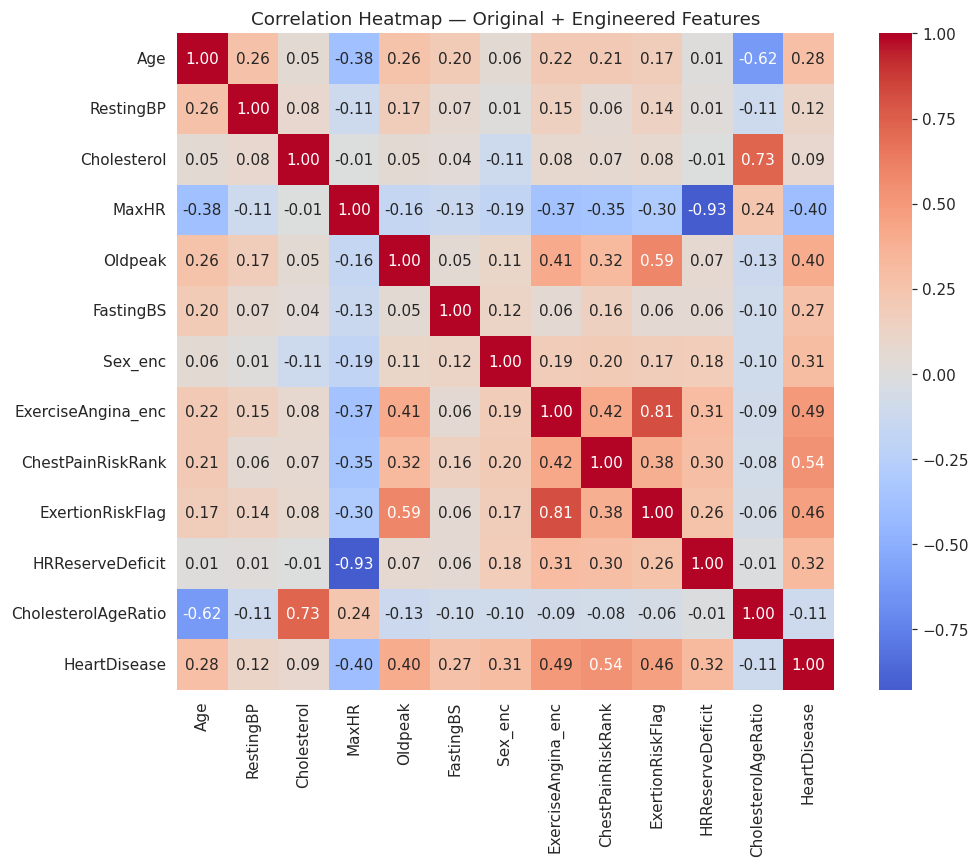

In [ ]:
# Build a numerically-encoded working frame purely for correlation/importance screening
work = df.copy()
work['Sex_enc'] = LabelEncoder().fit_transform(work['Sex'])
work['ExerciseAngina_enc'] = LabelEncoder().fit_transform(work['ExerciseAngina'])

screen_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','FastingBS',
               'Sex_enc','ExerciseAngina_enc','ChestPainRiskRank','ExertionRiskFlag',
               'HRReserveDeficit','CholesterolAgeRatio','HeartDisease']
screen_corr = work[screen_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(screen_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Original + Engineered Features')
plt.tight_layout()
plt.show()

print("Pairs with |correlation| > 0.7:")
cols = screen_corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        v = screen_corr.iloc[i, j]
        if abs(v) > 0.7:
            print(f"  {cols[i]:20s} <-> {cols[j]:20s}  r = {v:.3f}")

Two flags come out of this check:

- **`HRReserveDeficit` ↔ `MaxHR`, r = -0.93.** This confirms what Part 6.4
  already suspected — the two are carrying almost identical information.
  Keeping both would add a near-duplicate column without adding new
  signal, and would inflate multicollinearity in any linear model trained
  later. **Decision: drop `HRReserveDeficit`, keep `MaxHR`** (MaxHR is the
  original, directly-measured variable and is easier for a
  non-technical audience to interpret than a derived deficit score).
- **`ExertionRiskFlag` ↔ `ExerciseAngina_enc`, r ≈ 0.81**, and a
  meaningful (0.59) correlation with Oldpeak. This is expected — the flag
  is *built from* both — but it's high enough to note. I'm not treating
  this the same as the MaxHR/HRReserveDeficit case, because the flag
  isn't a disguised copy of one column, it's a genuine interaction of two,
  and the Random Forest check below (7.2) shows it still contributes
  importance beyond what `ExerciseAngina` and `Oldpeak` provide alone.

### 7.2 Feature Importance — Random Forest (Ranking Tool, Not the Final Model)

ST_Slope_Up          0.154
ST_Slope_Flat        0.105
ChestPainRiskRank    0.104
Oldpeak              0.103
MaxHR                0.100
Cholesterol          0.080
Age                  0.080
RestingBP            0.074
ExerciseAngina       0.064
ExertionRiskFlag     0.044
Sex                  0.040
FastingBS            0.026
RestingECG_Normal    0.015
RestingECG_ST        0.010
dtype: float64


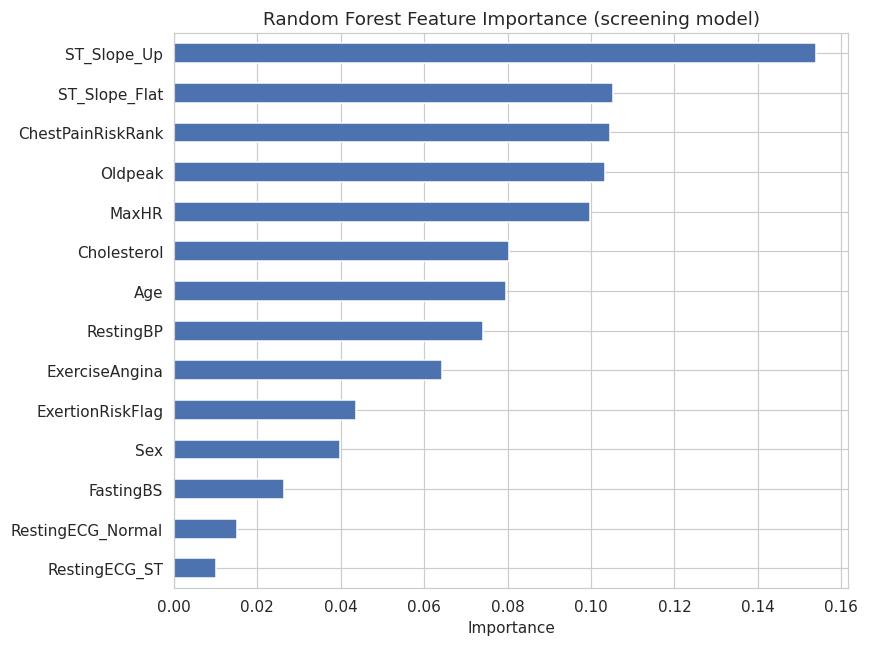

In [ ]:
importance_df = df.copy()
importance_df['Sex'] = LabelEncoder().fit_transform(importance_df['Sex'])
importance_df['ExerciseAngina'] = LabelEncoder().fit_transform(importance_df['ExerciseAngina'])
importance_df = pd.get_dummies(importance_df, columns=['RestingECG', 'ST_Slope'], drop_first=True)

drop_cols = ['ChestPainType', 'AgeGroup' if 'AgeGroup' in importance_df.columns else 'HeartDisease',
             'BPCategory', 'HRReserveDeficit', 'CholesterolAgeRatio', 'HeartDisease']
drop_cols = [c for c in dict.fromkeys(drop_cols) if c in importance_df.columns]
X = importance_df.drop(columns=drop_cols)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)
y = importance_df['HeartDisease']

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X, y)
feat_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_importance.plot(kind='barh', color='#4C72B0')
plt.title('Random Forest Feature Importance (screening model)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_importance.round(3))

`ChestPainRiskRank` lands in the top 3, right behind the two `ST_Slope`
dummies and ahead of every raw numeric column except `MaxHR` — strong,
independent confirmation that the ordinal re-encoding from Part 6.1 kept
(and arguably concentrated) the signal that used to be spread across four
one-hot columns. `ExertionRiskFlag` sits lower but still clears a
meaningful, non-trivial importance score, supporting the decision to keep
it despite its correlation with its parent columns.

### 7.3 Feature-by-Feature Decisions

| Feature | Evidence | Decision | Why |
|---|---|---|---|
| `MaxHR` | Test 1, r=-0.93 vs HRReserveDeficit | **Retain** | Strong, direct signal; kept over its derived deficit version |
| `Oldpeak` | Test 2, top-5 RF importance | **Retain** | One of the strongest single predictors in the dataset |
| `ChestPainType` (raw) | Test 3 | **Retain (context), replaced for modelling** | Kept in the human-readable refined dataset; replaced by `ChestPainRiskRank` in the ML-ready encoding (7.4) |
| `ExerciseAngina` | Test 4 | **Retain** | Strong standalone signal even with `ExertionRiskFlag` present |
| `Cholesterol` | Test 5 (small effect across CP types) | **Retain** | Still independently associated with the target; small effect from Test 5 was across chest-pain groups, not against the target directly |
| `Sex` | Test 6 | **Retain** | Significant association; flagged for fairness monitoring, not removal |
| `ChestPainRiskRank` (new) | r=0.537 with target, top-3 RF importance | **Retain — replaces one-hot `ChestPainType` in final ML set** | Strongest engineered feature; preserves a genuine monotonic pattern in one column |
| `ExertionRiskFlag` (new) | Cramer's V=0.46, non-trivial RF importance | **Retain** | Adds interaction signal beyond either parent column alone |
| `BPCategory` (new) | Weakest significant test (p=0.007) | **Retain for reporting only, dropped from ML-ready set** | A coarsened copy of `RestingBP`, which is already in the model; useful for HR-facing reporting, not for the model itself |
| `HRReserveDeficit` (new) | r=-0.93 with MaxHR | **Drop** | Near-total redundancy with MaxHR; adds no independent information |
| `CholesterolAgeRatio` (new) | Sign-flipped vs raw Cholesterol (7.4/6.5) | **Drop** | Confounded by Age; direction of relationship with target is unreliable and would mislead a non-technical reader |
| `RiskFactorCount` (Week 2) | Low individual RF importance, per Week 2 report | **Retain (no new evidence to revisit)** | Costs nothing to keep; Week 2 already justified this call and this week's analysis found no reason to reopen it |
| `AgeGroup` (Week 2) | No new evidence gathered this week | **Retain (no new evidence to revisit)** | Same reasoning — not re-litigating a Week 2 decision without cause |

No feature was removed purely for being correlated with another — the two
removals (`HRReserveDeficit`, `CholesterolAgeRatio`) were both dropped
because the evidence showed they added no independent value or were
actively misleading, not simply because they existed alongside a related
column.

## 8. Dataset Refinement — Building the Final Modelling Dataset

Two outputs, matching the pattern Week 2 already established:

1. A **refined, human-readable dataset** — Week 2's cleaned data plus the
   three retained engineered features in their plain form (including
   `BPCategory`, kept here for reporting even though it won't travel into
   the ML-ready version).
2. A **final ML-ready dataset** — encoded and scaled, replacing Week 2's
   `heart_ml_ready.csv` with the Part 7 decisions folded in: the two
   dropped features left out, `ChestPainRiskRank` standing in for the old
   `ChestPainType` one-hot columns, and `ExertionRiskFlag` added in.

No cleaning steps from Week 2 are being redone — this section only adds,
removes, and re-encodes based on the evidence gathered this week.

In [ ]:
refined = df.drop(columns=['HRReserveDeficit', 'CholesterolAgeRatio']).copy()
print(f"Refined (human-readable) dataset shape: {refined.shape}")
refined.head(3)

Refined (human-readable) dataset shape: (918, 15)


In [ ]:
ml_ready = df.copy()

# Recreate the Week 2 engineered features consistently with the Week 2 report's logic
def age_group(a):
    if a < 40: return 'Under40'
    elif a < 50: return '40-49'
    elif a < 60: return '50-59'
    else: return '60+'
ml_ready['AgeGroup'] = ml_ready['Age'].apply(age_group)

chol_high = (ml_ready['Cholesterol'] > ml_ready['Cholesterol'].median()).astype(int)
bp_high = (ml_ready['RestingBP'] > ml_ready['RestingBP'].median()).astype(int)
angina_flag = (ml_ready['ExerciseAngina'] == 'Y').astype(int)
ml_ready['RiskFactorCount'] = ml_ready['FastingBS'] + angina_flag + chol_high + bp_high

# Drop the two features Part 7 decided against, and BPCategory (reporting-only)
ml_ready = ml_ready.drop(columns=['HRReserveDeficit', 'CholesterolAgeRatio', 'BPCategory'])

# Rename for readability, consistent with Week 2's naming convention
ml_ready = ml_ready.rename(columns={
    'FastingBS': 'FastingBloodSugarHigh',
    'Oldpeak': 'ST_Depression',
    'MaxHR': 'MaxHeartRate',
})

# Encode
ml_ready['Sex'] = LabelEncoder().fit_transform(ml_ready['Sex'])
ml_ready['ExerciseAngina'] = LabelEncoder().fit_transform(ml_ready['ExerciseAngina'])
# ChestPainType is dropped -- fully replaced by the already-numeric ChestPainRiskRank
ml_ready = ml_ready.drop(columns=['ChestPainType'])
ml_ready = pd.get_dummies(ml_ready, columns=['RestingECG', 'ST_Slope', 'AgeGroup'], drop_first=True)
bool_cols = ml_ready.select_dtypes(include='bool').columns
ml_ready[bool_cols] = ml_ready[bool_cols].astype(int)

# Scale continuous numeric columns only -- leave binary flags, ordinal rank and one-hot dummies unscaled... 
# actually scale ChestPainRiskRank too, consistent with Week 2's scaling of RiskFactorCount as a numeric feature
scale_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHeartRate', 'ST_Depression',
              'RiskFactorCount', 'ChestPainRiskRank']
scaler = StandardScaler()
ml_ready[scale_cols] = scaler.fit_transform(ml_ready[scale_cols])

print(f"Final ML-ready dataset shape: {ml_ready.shape}")
print(f"\nColumns ({len(ml_ready.columns)}):")
print(list(ml_ready.columns))
ml_ready.head(3)

Final ML-ready dataset shape: (918, 19)

Columns (19):
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBloodSugarHigh', 'MaxHeartRate', 'ExerciseAngina', 'ST_Depression', 'HeartDisease', 'ChestPainRiskRank', 'ExertionRiskFlag', 'RiskFactorCount', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up', 'AgeGroup_50-59', 'AgeGroup_60+', 'AgeGroup_Under40']


The final ML-ready dataset has one fewer column than Week 2's version
(20 → 19) despite adding a new feature — because collapsing the 3
`ChestPainType` one-hot columns down into a single `ChestPainRiskRank`
column saved two columns, `ExertionRiskFlag` added one back, and
`BPCategory` (which was never in Week 2's ML-ready file to begin with)
stays in the refined/reporting version only. Smaller and — per Part 7's
evidence — no weaker.

In [ ]:
refined.to_csv('heart_week3_refined.csv', index=False)
ml_ready.to_csv('heart_final_modelling_dataset.csv', index=False)
print("Saved: heart_week3_refined.csv, heart_final_modelling_dataset.csv")

Saved: heart_week3_refined.csv, heart_final_modelling_dataset.csv


## 9. Summary

The full write-up of what this means for the business sits in the
**Business Insights and Recommendations Report** — this is just the
notebook-level recap.

- Six statistical tests, all significant; `ChestPainType`,
  `ExerciseAngina`, `Oldpeak` and `MaxHR` are the strongest individual
  signals in the dataset, with `Sex` also showing a large gap worth
  monitoring for fairness.
- Five new features were engineered from that evidence. Three earned a
  place in the final dataset (`ChestPainRiskRank`, `ExertionRiskFlag`,
  and `BPCategory` for reporting); two were built, tested, and honestly
  dropped once the evidence showed they added no independent value
  (`HRReserveDeficit`) or were actively misleading (`CholesterolAgeRatio`).
- The final modelling dataset carries forward every original signal that
  tested as meaningful, drops nothing without a documented reason, and is
  ready to hand to Week 4.